In [1]:
from pathlib import Path
import time
import json

import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.arima.model import ARIMA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import (mean_absolute_error,mean_squared_error)

import requests
import joblib
from tqdm.notebook import trange, tqdm

DATA_RAW = Path("data/raw")
DATA_PROCESSED = Path("data/processed")
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)


In [2]:
base_path = Path(r"C:\Users\User\Desktop\dashboard\PROJECTS NOT ON GITHUB\finance-portfolio-analytics\Data\Raw\Kaggle_market_csv")

symbols_path = base_path / "symbols_valid_meta.csv"
prices_path  = base_path / "WIKI_PRICES.csv"

symbols_path, prices_path

(WindowsPath('C:/Users/User/Desktop/dashboard/PROJECTS NOT ON GITHUB/finance-portfolio-analytics/Data/Raw/Kaggle_market_csv/symbols_valid_meta.csv'),
 WindowsPath('C:/Users/User/Desktop/dashboard/PROJECTS NOT ON GITHUB/finance-portfolio-analytics/Data/Raw/Kaggle_market_csv/WIKI_PRICES.csv'))

In [3]:
df_meta = pd.read_csv(symbols_path)
print(df_meta.shape)
df_meta.head()


(8049, 12)


,Nasdaq Traded,Symbol,Security Name,Listing Exchange,Market Category,ETF,Round Lot Size,Test Issue,Financial Status,CQS Symbol,NASDAQ Symbol,NextShares
0,Y,A,"Agilent Technologies, Inc. Common Stock",N,,N,100.0,N,NaN,A,A,N
1,Y,AA,Alcoa Corporation Common Stock,N,,N,100.0,N,NaN,AA,AA,N
2,Y,AAAU,Perth Mint Physical Gold ETF,P,,Y,100.0,N,NaN,AAAU,AAAU,N
3,Y,AACG,ATA Creativity Global - American Depositary Sh...,Q,G,N,100.0,N,N,NaN,AACG,N
4,Y,AADR,AdvisorShares Dorsey Wright ADR ETF,P,,Y,100.0,N,NaN,AADR,AADR,N


In [4]:
df_prices = pd.read_csv(
    prices_path,
    parse_dates=["date"],
    infer_datetime_format=True,
    low_memory=False
)

print(df_prices.shape)
df_prices.head()


C:\Users\User\AppData\Local\Temp\ipykernel_19372\93082451.py:1: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df_prices = pd.read_csv(


(15389314, 14)


,ticker,date,open,high,low,close,volume,ex-dividend,split_ratio,adj_open,adj_high,adj_low,adj_close,adj_volume
0,A,1999-11-18,45.50,50.00,40.00,44.00,44739900.0,0.0,1.0,31.041951,34.112034,27.289627,30.018590,44739900.0
1,A,1999-11-19,42.94,43.00,39.81,40.38,10897100.0,0.0,1.0,29.295415,29.336350,27.160002,27.548879,10897100.0
2,A,1999-11-22,41.31,44.00,40.06,44.00,4705200.0,0.0,1.0,28.183363,30.018590,27.330562,30.018590,4705200.0
3,A,1999-11-23,42.50,43.63,40.25,40.25,4274400.0,0.0,1.0,28.995229,29.766161,27.460188,27.460188,4274400.0
4,A,1999-11-24,40.13,41.94,40.00,41.06,3464400.0,0.0,1.0,27.378319,28.613174,27.289627,28.012803,3464400.0


In [5]:
df_prices = df_prices.rename(columns=str.lower)

# rename for consistency
df_prices = df_prices.rename(columns={
    "ticker": "symbol",
    "adj_close": "adj_close"
})

# Keep only essential columns
df_prices = df_prices[[
    "date", "symbol", "open", "high", "low", "close", "volume", "adj_close"
]]

df_prices.head()


,date,symbol,open,high,low,close,volume,adj_close
0,1999-11-18,A,45.50,50.00,40.00,44.00,44739900.0,30.018590
1,1999-11-19,A,42.94,43.00,39.81,40.38,10897100.0,27.548879
2,1999-11-22,A,41.31,44.00,40.06,44.00,4705200.0,30.018590
3,1999-11-23,A,42.50,43.63,40.25,40.25,4274400.0,27.460188
4,1999-11-24,A,40.13,41.94,40.00,41.06,3464400.0,28.012803


In [6]:
df_meta = df_meta.rename(columns=str.lower)

df_prices = df_prices.rename(columns=str.lower)
df_prices = df_prices.rename(columns={"ticker": "symbol"})

df_prices = df_prices[[
    "date", "symbol", "open", "high", "low", "close", "volume", "adj_close"
]]

df_merged = df_prices.merge(df_meta, on="symbol", how="left")
df_merged.head()


,date,symbol,open,high,low,close,volume,adj_close,nasdaq traded,security name,listing exchange,market category,etf,round lot size,test issue,financial status,cqs symbol,nasdaq symbol,nextshares
0,1999-11-18,A,45.50,50.00,40.00,44.00,44739900.0,30.018590,Y,"Agilent Technologies, Inc. Common Stock",N,,N,100.0,N,NaN,A,A,N
1,1999-11-19,A,42.94,43.00,39.81,40.38,10897100.0,27.548879,Y,"Agilent Technologies, Inc. Common Stock",N,,N,100.0,N,NaN,A,A,N
2,1999-11-22,A,41.31,44.00,40.06,44.00,4705200.0,30.018590,Y,"Agilent Technologies, Inc. Common Stock",N,,N,100.0,N,NaN,A,A,N
3,1999-11-23,A,42.50,43.63,40.25,40.25,4274400.0,27.460188,Y,"Agilent Technologies, Inc. Common Stock",N,,N,100.0,N,NaN,A,A,N
4,1999-11-24,A,40.13,41.94,40.00,41.06,3464400.0,28.012803,Y,"Agilent Technologies, Inc. Common Stock",N,,N,100.0,N,NaN,A,A,N


In [7]:
out_path = Path(r"C:\Users\User\Desktop\dashboard\PROJECTS NOT ON GITHUB\finance-portfolio-analytics\Data\Processed")

df_prices.to_parquet(out_path / "kaggle_prices_clean.parquet", index=False)
df_meta.to_parquet(out_path / "kaggle_metadata.parquet", index=False)


In [8]:
import os

API_KEY = "DY30DH46GLTR9VEQ"   


In [9]:
import requests


def get_alpha_daily_free(symbol, api_key):
    url = (
        "https://www.alphavantage.co/query?"
        f"function=TIME_SERIES_DAILY&symbol={symbol}"
        f"&outputsize=compact&apikey={api_key}"
    )

    r = requests.get(url).json()

    if "Time Series (Daily)" not in r:
        print(f"❌ Error downloading {symbol} — {r}")
        return None

    df = pd.DataFrame(r["Time Series (Daily)"]).T
    df.index = pd.to_datetime(df.index)
    df.sort_index(inplace=True)

    df = df.rename(columns={
        "1. open": "open",
        "2. high": "high",
        "3. low": "low",
        "4. close": "close",
        "5. volume": "volume"
    })

    # free tier does NOT include adjusted close
    df = df[["open", "high", "low", "close", "volume"]].astype(float)

    df["symbol"] = symbol
    df = df.reset_index().rename(columns={"index": "date"})

    return df


In [10]:
df_test = get_alpha_daily_free("AAPL", API_KEY)
df_test.head()


,date,open,high,low,close,volume,symbol
0,2025-07-25,214.700,215.240,213.40,213.88,40268781.0,AAPL
1,2025-07-28,214.030,214.845,213.06,214.05,37858017.0,AAPL
2,2025-07-29,214.175,214.810,210.82,211.27,51411723.0,AAPL
3,2025-07-30,211.895,212.390,207.72,209.05,45512514.0,AAPL
4,2025-07-31,208.490,209.840,207.16,207.57,80698431.0,AAPL


In [11]:

base_path = Path(r"C:\Users\User\Desktop\dashboard\PROJECTS NOT ON GITHUB\finance-portfolio-analytics\Data\Processed")


In [12]:
kaggle_df = pd.read_parquet(base_path / "kaggle_prices_clean.parquet")
kaggle_df.head()


,date,symbol,open,high,low,close,volume,adj_close
0,1999-11-18,A,45.50,50.00,40.00,44.00,44739900.0,30.018590
1,1999-11-19,A,42.94,43.00,39.81,40.38,10897100.0,27.548879
2,1999-11-22,A,41.31,44.00,40.06,44.00,4705200.0,30.018590
3,1999-11-23,A,42.50,43.63,40.25,40.25,4274400.0,27.460188
4,1999-11-24,A,40.13,41.94,40.00,41.06,3464400.0,28.012803


In [13]:
# etl_kaggle.py


RAW_PATH = Path("../Data/Raw/Kaggle_market_csv")
PROCESSED_PATH = Path("../Data/Processed")
PROCESSED_PATH.mkdir(parents=True, exist_ok=True)

def load_kaggle():
    # Load symbol metadata
    df_meta = pd.read_csv(RAW_PATH / "symbols_valid_meta.csv")
    df_meta.columns = df_meta.columns.str.lower()
    df_meta.to_parquet(PROCESSED_PATH / "kaggle_metadata.parquet", index=False)
    
    # Load WIKI prices
    df_prices = pd.read_csv(RAW_PATH / "WIKI_PRICES.csv", parse_dates=["date"], low_memory=False)
    df_prices.columns = df_prices.columns.str.lower()
    
    # Keep only essential columns
    cols_needed = ["date","ticker","open","high","low","close","volume","adj_close"]
    df_prices = df_prices[[c for c in cols_needed if c in df_prices.columns]]
    df_prices = df_prices.rename(columns={"ticker":"symbol"})
    
    # Save parquet
    df_prices.to_parquet(PROCESSED_PATH / "kaggle_prices_clean.parquet", index=False)
    print("Kaggle ETL complete. Files saved to Processed folder.")

if __name__ == "__main__":
    load_kaggle()


Kaggle ETL complete. Files saved to Processed folder.


In [14]:
# etl_alpha.py
import requests


PROCESSED_PATH = Path("../Data/Processed")
PROCESSED_PATH.mkdir(parents=True, exist_ok=True)
API_KEY = "YOUR_ALPHA_VANTAGE_KEY"

def fetch_alpha(symbol):
    url = f"https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol={symbol}&outputsize=compact&apikey={API_KEY}"
    r = requests.get(url).json()
    if "Time Series (Daily)" not in r:
        print(f"Error fetching {symbol}: {r}")
        return None
    df = pd.DataFrame(r["Time Series (Daily)"]).T
    df.index = pd.to_datetime(df.index)
    df.sort_index(inplace=True)
    df = df.rename(columns={
        "1. open":"open","2. high":"high","3. low":"low","4. close":"close","5. volume":"volume"
    })
    df = df[["open","high","low","close","volume"]].astype(float)
    df["symbol"] = symbol
    df = df.reset_index().rename(columns={"index":"date"})
    return df

def run_alpha(symbols):
    all_data = []
    for sym in symbols:
        print(f"Fetching {sym}")
        df = fetch_alpha(sym)
        if df is not None:
            all_data.append(df)
        time.sleep(12)  # Respect free API rate limits
    if all_data:
        df_all = pd.concat(all_data, ignore_index=True)
        df_all.to_parquet(PROCESSED_PATH / "alpha_vantage_prices.parquet", index=False)
        print("Alpha Vantage ETL complete.")

if __name__ == "__main__":
    # Example: pick top 5 symbols (free API limit)
    symbols = ["AAPL","MSFT","AMZN","GOOGL","TSLA"]
    run_alpha(symbols)
    

Fetching AAPL
Fetching MSFT
Fetching AMZN
Fetching GOOGL
Fetching TSLA
Alpha Vantage ETL complete.


In [15]:
# merge_market_data.py
import pandas as pd
from pathlib import Path

PROCESSED_PATH = Path("../Data/Processed")

kaggle_file = PROCESSED_PATH / "kaggle_prices_clean.parquet"
alpha_file  = PROCESSED_PATH / "alpha_vantage_prices.parquet"

kaggle_df = pd.read_parquet(kaggle_file)
alpha_df = pd.read_parquet(alpha_file)

# Standardize
kaggle_df['date'] = pd.to_datetime(kaggle_df['date'])
alpha_df['date'] = pd.to_datetime(alpha_df['date'])

# Ensure numeric
for col in ["open","high","low","close","volume"]:
    kaggle_df[col] = pd.to_numeric(kaggle_df[col], errors='coerce')
    alpha_df[col] = pd.to_numeric(alpha_df[col], errors='coerce')

# Merge
merged_df = pd.concat([kaggle_df, alpha_df], ignore_index=True)
merged_df = merged_df.sort_values(["symbol","date"])
merged_df = merged_df.drop_duplicates(subset=["symbol","date"], keep="last")
merged_df = merged_df.reset_index(drop=True)

# Save final merged dataset
merged_df.to_parquet(PROCESSED_PATH / "market_data_merged.parquet", index=False)
print("Merged dataset saved:", PROCESSED_PATH / "market_data_merged.parquet")


Merged dataset saved: ..\Data\Processed\market_data_merged.parquet


In [16]:
# Cell 1: imports & paths
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib
from tqdm.notebook import tqdm

# Paths (adjust if needed)
BASE = Path(r"C:\Users\User\Desktop\dashboard\PROJECTS NOT ON GITHUB\finance-portfolio-analytics")
PROCESSED = BASE / "data" / "processed"
OUTPUTS = BASE / "outputs"
MODEL_DIR = OUTPUTS / "model_artifacts"
PBI_DIR = OUTPUTS / "powerbi_exports"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
PBI_DIR.mkdir(parents=True, exist_ok=True)

print("Using processed folder:", PROCESSED)


Using processed folder: C:\Users\User\Desktop\dashboard\PROJECTS NOT ON GITHUB\finance-portfolio-analytics\data\processed


In [17]:
# Cell 2: load merged data
merged = pd.read_parquet(PROCESSED / "market_data_merged.parquet")
merged['date'] = pd.to_datetime(merged['date'])
merged = merged.sort_values(['symbol','date']).reset_index(drop=True)

print("Rows:", len(merged), "Symbols:", merged['symbol'].nunique())
merged.head()


Rows: 15389814 Symbols: 3199


,date,symbol,open,high,low,close,volume,adj_close
0,1999-11-18,A,45.50,50.00,40.00,44.00,44739900.0,30.018590
1,1999-11-19,A,42.94,43.00,39.81,40.38,10897100.0,27.548879
2,1999-11-22,A,41.31,44.00,40.06,44.00,4705200.0,30.018590
3,1999-11-23,A,42.50,43.63,40.25,40.25,4274400.0,27.460188
4,1999-11-24,A,40.13,41.94,40.00,41.06,3464400.0,28.012803


In [18]:
# Cell 3: EDA
print("Date range:", merged['date'].min(), "to", merged['date'].max())
print("Top symbols by row count:")
print(merged['symbol'].value_counts().head(10))

# check for duplicates
dups = merged.duplicated(subset=['symbol','date']).sum()
print("Duplicate (symbol,date) rows:", dups)

# missing values summary
print(merged.isna().sum())


Date range: 1962-01-02 00:00:00 to 2025-12-15 00:00:00
Top symbols by row count:
symbol
HPQ     14155
ARNC    14155
CAT     14155
GE      14155
KO      14155
DIS     14155
BA      14155
IBM     14155
DD      14014
CVX     12168
Name: count, dtype: int64
Duplicate (symbol,date) rows: 0
date           0
symbol         0
open         538
high          55
low           55
close          1
volume         0
adj_close    501
dtype: int64


In [19]:
# Cell 4: returns per symbol
merged = merged.sort_values(['symbol','date'])
merged['close'] = pd.to_numeric(merged['close'], errors='coerce')
merged['return'] = merged.groupby('symbol')['close'].pct_change()
# drop rows without return (first day per symbol)
print("Non-NaN returns:", merged['return'].notna().sum())
merged.head()


Non-NaN returns: 15386615


,date,symbol,open,high,low,close,volume,adj_close,return
0,1999-11-18,A,45.50,50.00,40.00,44.00,44739900.0,30.018590,NaN
1,1999-11-19,A,42.94,43.00,39.81,40.38,10897100.0,27.548879,-0.082273
2,1999-11-22,A,41.31,44.00,40.06,44.00,4705200.0,30.018590,0.089648
3,1999-11-23,A,42.50,43.63,40.25,40.25,4274400.0,27.460188,-0.085227
4,1999-11-24,A,40.13,41.94,40.00,41.06,3464400.0,28.012803,0.020124


In [20]:
# Cell 5: simple portfolio construction (equal-weighted top-N symbols)
N = 5   # choose top N symbols to include
top_syms = merged['symbol'].value_counts().head(N).index.tolist()
print("Top symbols:", top_syms)

# choose a snapshot of net_qty per symbol for demonstration - equal weight
weights = {s: 1.0/N for s in top_syms}

# create daily portfolio value: for each date sum(weight * close)
daily = (
    merged[merged['symbol'].isin(top_syms)]
    .loc[:, ['date','symbol','close']]
    .pivot(index='date', columns='symbol', values='close')
    .sort_index()
)

# forward-fill missing prices (if trading day absent for a symbol) — careful: only if you know this is appropriate
daily = daily.ffill()

# portfolio value (assume starting capital 1)
# equal-weighted portfolio value series (weights sum to 1)
portfolio_val = (daily.fillna(method='ffill') * pd.Series(weights)).sum(axis=1)
portfolio_df = pd.DataFrame({'date': portfolio_val.index, 'value': portfolio_val.values})
portfolio_df = portfolio_df.sort_values('date').reset_index(drop=True)
portfolio_df['daily_return'] = portfolio_df['value'].pct_change()
portfolio_df = portfolio_df.dropna().reset_index(drop=True)
portfolio_df.head()


Top symbols: ['HPQ', 'ARNC', 'CAT', 'GE', 'KO']


,date,value,daily_return
0,1962-01-03,62.524,-0.006388
1,1962-01-04,62.552,0.000448
2,1962-01-05,61.626,-0.014804
3,1962-01-08,61.102,-0.008503
4,1962-01-09,61.648,0.008936


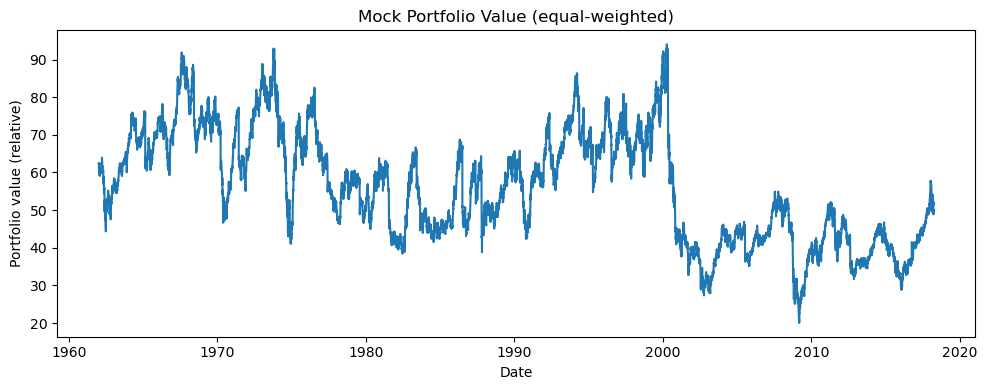

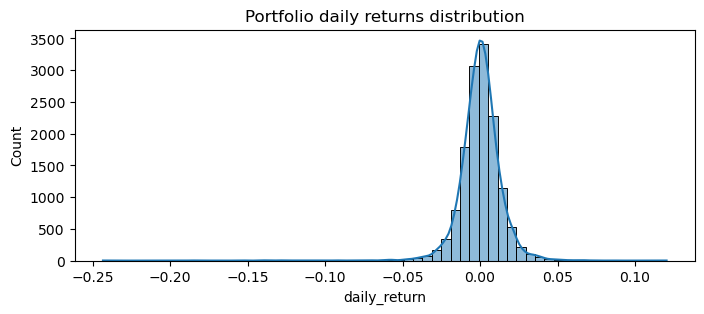

In [21]:
# Cell 6: plots
plt.figure(figsize=(10,4))
plt.plot(portfolio_df['date'], portfolio_df['value'])
plt.title("Mock Portfolio Value (equal-weighted)")
plt.xlabel("Date")
plt.ylabel("Portfolio value (relative)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,3))
sns.histplot(portfolio_df['daily_return'].dropna(), bins=60, kde=True)
plt.title("Portfolio daily returns distribution")
plt.show()


In [22]:
# Cell 7: ARIMA baseline
series = portfolio_df.set_index('date')['daily_return'].dropna()

# Brief stationarity check is skipped for brevity — differencing with order 1 is common for returns
order = (5,0,0)  # since series is returns we don't difference (d=0); adjust if needed
print("Fitting ARIMA", order)
model = ARIMA(series, order=order)
res = model.fit()
print(res.summary())

# Forecast next 14 trading days (these are return forecasts)
steps = 14
fc = res.forecast(steps=steps)
fc.index = pd.date_range(start=portfolio_df['date'].max() + pd.Timedelta(days=1), periods=steps, freq='B')  # business days
arima_fc = pd.DataFrame({'date': fc.index, 'arima_return': fc.values})
arima_fc.head()

# save arima forecast for PowerBI
arima_fc.to_csv(PBI_DIR / "arima_forecast.csv", index=False)


Fitting ARIMA (5, 0, 0)


C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\User\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:           daily_return   No. Observations:                14154
Model:                 ARIMA(5, 0, 0)   Log Likelihood               40035.505
Date:                Tue, 16 Dec 2025   AIC                         -80057.010
Time:                        12:31:34   BIC                         -80004.106
Sample:                             0   HQIC                        -80039.407
                              - 14154                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       8.838e-05      0.000      0.653      0.514      -0.000       0.000
ar.L1          0.0279      0.007      4.264      0.000       0.015       0.041
ar.L2         -0.0182      0.006     -3.127      0.0

C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [23]:
# Cell 8: ARIMA one-step rolling backtest
from tqdm.notebook import trange
series = series.dropna()
T = len(series)
test_size = int(T * 0.2)
train_end = T - test_size

preds = []
truth = []
dates = []

# rolling one-step forecast
for i in trange(train_end, train_end + 300):
    train_series = series.iloc[:i]
    model = ARIMA(train_series, order=order).fit()
    pred = model.forecast(steps=1).iloc[0]
    preds.append(pred)
    truth.append(series.iloc[i])
    dates.append(series.index[i])

arima_backtest = pd.DataFrame({'date': dates, 'pred': preds, 'actual': truth})
arima_backtest['error'] = arima_backtest['actual'] - arima_backtest['pred']

# metrics
def mape(y_true, y_pred):
    return (np.abs((y_true - y_pred) / (y_true.replace(0, np.nan)))).dropna().mean() * 100

mae = mean_absolute_error(arima_backtest['actual'], arima_backtest['pred'])
rmse = mean_squared_error(arima_backtest['actual'], arima_backtest['pred'], squared=False)
mape_val = mape(arima_backtest['actual'], arima_backtest['pred'])
dir_acc = (np.sign(arima_backtest['actual']) == np.sign(arima_backtest['pred'])).mean()

print(f"ARIMA backtest MAE={mae:.6f}, RMSE={rmse:.6f}, MAPE={mape_val:.2f}%, Direction Acc={dir_acc:.3f}")


  0%|          | 0/300 [00:00<?, ?it/s]

C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users

C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates,

C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates,

C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates,

...

C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates,

C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates,

C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates,

ARIMA backtest MAE=0.008597, RMSE=0.011319, MAPE=106.62%, Direction Acc=0.530


C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\User\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [24]:
# Cell 9: features dataframe (portfolio)
df = portfolio_df.set_index('date').copy()
df['ret'] = df['daily_return']
df['lag1'] = df['ret'].shift(1)
df['lag2'] = df['ret'].shift(2)
df['lag3'] = df['ret'].shift(3)
df['roll_mean_7'] = df['ret'].rolling(7).mean()
df['roll_std_7'] = df['ret'].rolling(7).std()
df['roll_mean_21'] = df['ret'].rolling(21).mean()
df = df.dropna().reset_index()
df.head()


,date,value,daily_return,ret,lag1,lag2,lag3,roll_mean_7,roll_std_7,roll_mean_21
0,1962-01-31,60.624,0.021879,0.021879,0.004232,-0.001285,-0.003303,-0.000589,0.011802,-0.001721
1,1962-02-01,60.652,0.000462,0.000462,0.021879,0.004232,-0.001285,0.001879,0.009407,-0.001395
2,1962-02-02,60.826,0.002869,0.002869,0.000462,0.021879,0.004232,0.002646,0.009207,-0.001279
3,1962-02-05,60.526,-0.004932,-0.004932,0.002869,0.000462,0.021879,0.002846,0.008993,-0.000809
4,1962-02-06,60.350,-0.002908,-0.002908,-0.004932,0.002869,0.000462,0.002902,0.008949,-0.000543


In [25]:
# Cell 10: train/test split
features = ['lag1','lag2','lag3','roll_mean_7','roll_std_7','roll_mean_21']
target = 'ret'

train_frac = 0.8
split_idx = int(len(df) * train_frac)
train = df.iloc[:split_idx].copy()
test  = df.iloc[split_idx:].copy()

X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

# RandomForest
rf = RandomForestRegressor(n_estimators=200, random_state=0)
rf.fit(X_train, y_train)
preds = rf.predict(X_test)

# metrics
mae_rf = mean_absolute_error(y_test, preds)
rmse_rf = mean_squared_error(y_test, preds, squared=False)
mape_rf = mape(y_test, preds)
dir_acc_rf = (np.sign(y_test) == np.sign(preds)).mean()

print(f"RF test MAE={mae_rf:.6f}, RMSE={rmse_rf:.6f}, MAPE={mape_rf:.2f}%, DirAcc={dir_acc_rf:.3f}")


RF test MAE=0.009077, RMSE=0.013390, MAPE=173196321032.11%, DirAcc=0.635


In [26]:
# Cell 11: rolling retrain backtest
window_train = int(len(df) * 0.6)  # initial training window
horizon = 1  # one-day ahead
preds = []
true = []
dates = []

Max_steps = 300
for i in trange(window_train, window_train + Max_steps ):
    train_slice = df.iloc[:i]
    test_slice = df.iloc[i:i+horizon]
    X_tr = train_slice[features]
    y_tr = train_slice[target]
    X_val = test_slice[features]
    y_val = test_slice[target]
    
    m = RandomForestRegressor(n_estimators=100, random_state=0)
    m.fit(X_tr, y_tr)
    p = m.predict(X_val)[0]
    
    preds.append(p)
    true.append(y_val.values[0])
    dates.append(test_slice['date'].values[0])

ml_backtest = pd.DataFrame({'date': dates, 'pred': preds, 'actual': true})
mae_bt = mean_absolute_error(ml_backtest['actual'], ml_backtest['pred'])
rmse_bt = mean_squared_error(ml_backtest['actual'], ml_backtest['pred'], squared=False)
mape_bt = mape(ml_backtest['actual'], ml_backtest['pred'])
dir_acc_bt = (np.sign(ml_backtest['actual']) == np.sign(ml_backtest['pred'])).mean()

print(f"RF rolling MAE={mae_bt:.6f}, RMSE={rmse_bt:.6f}, MAPE={mape_bt:.2f}%, DirAcc={dir_acc_bt:.3f}")


  0%|          | 0/300 [00:00<?, ?it/s]

RF rolling MAE=0.008213, RMSE=0.012021, MAPE=408.40%, DirAcc=0.637


In [27]:
# Cell 12: fit on full training set and save
rf_full = RandomForestRegressor(n_estimators=200, random_state=0)
rf_full.fit(X_train, y_train)
joblib.dump(rf_full, MODEL_DIR / "rf_portfolio.joblib")
# Save features list and metadata
import json
with open(MODEL_DIR / "rf_portfolio_meta.json", "w") as f:
    json.dump({"features":features, "trained_on": str(df['date'].iloc[:split_idx].min()) + " to " + str(df['date'].iloc[:split_idx].max())}, f)
print("Model saved to", MODEL_DIR)


Model saved to C:\Users\User\Desktop\dashboard\PROJECTS NOT ON GITHUB\finance-portfolio-analytics\outputs\model_artifacts


In [28]:
# Cell 13: Next-14-day forecasts
last_row = df.iloc[-1:].copy()

# ARIMA forecast (we already have arima_fc)
# ML recursive forecast using naive rolling of features
ml_preds = []
cur_window = df['ret'].iloc[-21:].tolist()  # last 21 returns for rolling stats
for i in range(14):
    lag1 = cur_window[-1]
    lag2 = cur_window[-2] if len(cur_window) >=2 else 0.0
    lag3 = cur_window[-3] if len(cur_window) >=3 else 0.0
    roll_mean_7 = np.mean(cur_window[-7:]) if len(cur_window) >=7 else np.mean(cur_window)
    roll_std_7 = np.std(cur_window[-7:]) if len(cur_window) >=7 else np.std(cur_window)
    roll_mean_21 = np.mean(cur_window[-21:]) if len(cur_window) >=21 else np.mean(cur_window)
    feat = np.array([lag1,lag2,lag3,roll_mean_7,roll_std_7,roll_mean_21]).reshape(1,-1)
    p = rf_full.predict(feat)[0]
    ml_preds.append(p)
    # update cur_window
    cur_window.append(p)

# build forecast DataFrames (dates = business days)
fc_dates = pd.date_range(start=portfolio_df['date'].max() + pd.Timedelta(days=1), periods=14, freq='B')
arima_fc = pd.read_csv(PBI_DIR / "arima_forecast.csv") if (PBI_DIR / "arima_forecast.csv").exists() else None
ml_fc = pd.DataFrame({'date': fc_dates, 'ml_return': ml_preds})
ml_fc.to_csv(PBI_DIR / "ml_forecast.csv", index=False)
print("Saved ml_forecast.csv")


C:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWar

Saved ml_forecast.csv


C:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


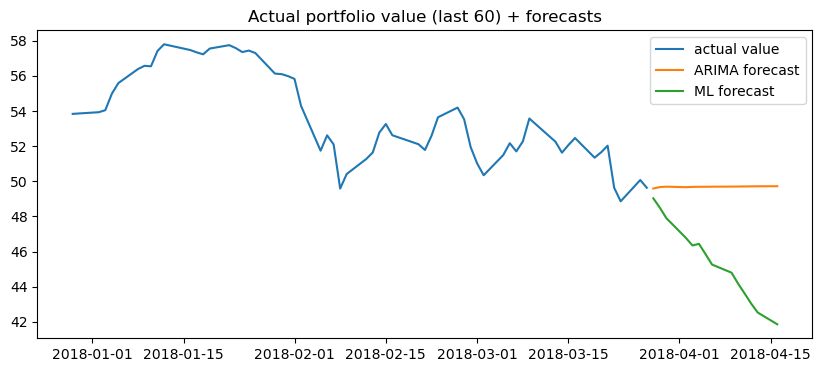

In [29]:
# Cell 14: plot last 60 days + forecasts
last_n = 60
hist = portfolio_df.set_index('date').loc[:, 'value'].iloc[-last_n:]
plt.figure(figsize=(10,4))
plt.plot(hist.index, hist.values, label='actual value')
# convert returns forecast to price path (approx)
last_val = hist.values[-1]
# ARIMA returns -> price path
if arima_fc is not None:
    arima_returns = arima_fc['arima_return'].values
    arima_prices = [last_val]
    for r in arima_returns:
        arima_prices.append(arima_prices[-1]*(1+r))
    plt.plot(pd.to_datetime(arima_fc['date']), arima_prices[1:], label='ARIMA forecast')
# ML
ml_prices = [last_val]
for r in ml_preds:
    ml_prices.append(ml_prices[-1]*(1+r))
plt.plot(fc_dates, ml_prices[1:], label='ML forecast')
plt.legend()
plt.title("Actual portfolio value (last {}) + forecasts".format(last_n))
plt.show()


In [30]:
# Cell 15: save performance metrics
perf = {
    "arima_mae": float(mae),
    "arima_rmse": float(rmse),
    "arima_mape_pct": float(mape_val),
    "arima_dir_acc": float(dir_acc),
    "rf_test_mae": float(mae_rf),
    "rf_test_rmse": float(rmse_rf),
    "rf_test_mape_pct": float(mape_rf),
    "rf_test_dir_acc": float(dir_acc_rf),
    "rf_rolling_mae": float(mae_bt),
    "rf_rolling_rmse": float(rmse_bt),
    "rf_rolling_mape_pct": float(mape_bt),
    "rf_rolling_dir_acc": float(dir_acc_bt)
}
import json
with open(MODEL_DIR / "model_performance.json", "w") as f:
    json.dump(perf, f, indent=2)
pd.DataFrame([perf]).to_csv(PBI_DIR / "model_performance_summary.csv", index=False)
print("Saved performance summary.")


Saved performance summary.


In [31]:
# Ensure market_df exists
market_df = merged[['date', 'symbol', 'close']].copy()

# Example positions (replace with real positions source if available)
positions_df = pd.DataFrame({
    "symbol": market_df['symbol'].unique(),
    "net_qty": 1.0
})

# Build portfolio
portfolio_df = (
    market_df
    .merge(positions_df, on="symbol", how="inner")
)

portfolio_df["portfolio_value"] = (
    portfolio_df["close"] * portfolio_df["net_qty"]
)

# Aggregate to daily portfolio level
daily_portfolio = (
    portfolio_df
    .groupby("date", as_index=False)["portfolio_value"]
    .sum()
)

daily_portfolio["daily_return"] = daily_portfolio["portfolio_value"].pct_change()

# ---- Power BI export ----
pbi_file = PBI_DIR / "daily_portfolio.csv"
daily_portfolio.to_csv(pbi_file, index=False)

print("Power BI portfolio file saved to:", pbi_file)
daily_portfolio.head()


Power BI portfolio file saved to: C:\Users\User\Desktop\dashboard\PROJECTS NOT ON GITHUB\finance-portfolio-analytics\outputs\powerbi_exports\daily_portfolio.csv


,date,portfolio_value,daily_return
0,1962-01-02,1215.38,NaN
1,1962-01-03,1220.12,0.003900
2,1962-01-04,1212.26,-0.006442
3,1962-01-05,1189.01,-0.019179
4,1962-01-08,1172.38,-0.013986
